# Naive Bayes Credit Risk


The Naive Bayes classifier is a simple yet powerful machine learning algorithm. It is based on Bayes' theorem and the theory of conditional probability. Despite its simplicity and the 'naive' assumption, Naive Bayes can be surprisingly effective in many real-world scenarios, such as text classification tasks like spam filtering and sentiment analysis.

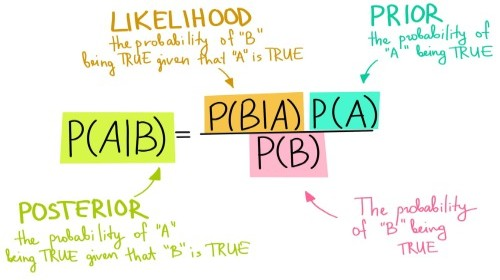

In this project, we will get a taste of applying this algorithm to a credit assessment task.

Suppose you are the manager of a bank. People from all backgrounds apply for loans at your bank for various purposes. Good clients duly repay their loans. However, bad clients do not repay their loans, which is also known as "defaulting" the loan. If the bad clients continue to default their loans, then your bank loses money. Your task is to use the information about the clients to predict whether a client will default on their loan.

this project will be divided into 3 sections.
- <b>Section 1</b> Preprocessing and visualizing the dataset (1 task to complete)
- <b>Section 2</b> Building the classifier (3 tasks to complete)
- <b>Section 3</b> Model evaluation (no tasks to complete)

## <b>Section 1:</b> Preprocessing and Visualizing the Dataset (1 task to complete)

Let's first load the dataset.  Upload `credit_risk_dataset_cleaned.csv` to the small folder icon on the left side in Google Colab.

In [1]:
# Loading the dataset
import pandas as pd
import numpy as np

df = pd.read_csv('credit_risk_dataset_cleaned.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,cb_person_default_on_file,loan_status
0,25,9600,MORTGAGE,1.0,MEDICAL,C,N,1
1,23,65500,RENT,4.0,MEDICAL,C,N,1
2,24,54400,RENT,8.0,MEDICAL,C,Y,1
3,26,77100,RENT,8.0,EDUCATION,B,N,1
4,24,78956,RENT,5.0,MEDICAL,B,N,1
...,...,...,...,...,...,...,...,...
23914,36,48686,RENT,21.0,MEDICAL,D,N,0
23915,36,44000,RENT,4.0,DEBTCONSOLIDATION,D,N,1
23916,37,90000,MORTGAGE,11.0,DEBTCONSOLIDATION,A,N,0
23917,38,110000,MORTGAGE,5.0,MEDICAL,B,N,0


The dataset contains the following columns:
- `person_age`: The age of the person
- `person_income`: The monthly income of the person
- `person_home_ownership`: The ownership status of their houses. Can be either `MORTGAGE` or `RENT`
- `person_emp_length`: The number of years the person has worked at their current job
- `loan_intent`: The person's reason for the loan application. Can be one of `MEDICAL`, `EDUCATION`, `PERSONAL`, `VENTURE`, or `DEBTCONSOLIDATION`
- `loan_grade`: The grade assigned to the loan based on the creditworthiness of the borrower. Grade `A` is the most trustworthy and `D` the least. Can be one of `A`, `B`, `C`, or `D`.
- `cb_person_default_on_file`: Whether the person has defaulted before. `Y` means yes and `N` means no.
- `loan_status`: Whether the loan is defaulted in the end. `0` means the loan is non-default and `1` means the loan is defaulted.

Before working on the dataset, it is helpful to first get an idea of what the dataset looks like.  You can use the following code to visualize the columns:

loan_grade
A    8212
B    8031
C    4977
D    2699
Name: count, dtype: int64

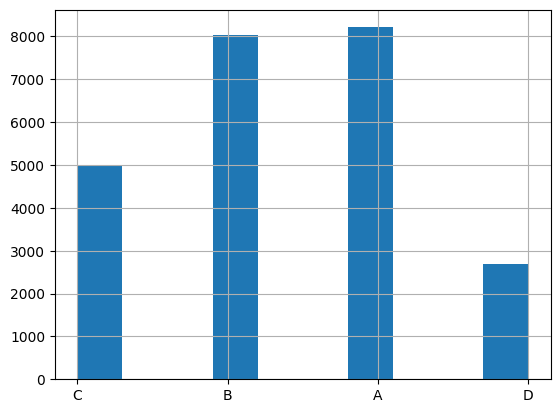

In [2]:
df['loan_grade'].hist() # plots a histogram
df['loan_grade'].value_counts() # prints the exact counts

You can also plot a covariance matrix among the different columns. Do you remember what the "naive" assumption in the Naive Bayes classifier is? How well does this dataset match this assumption?

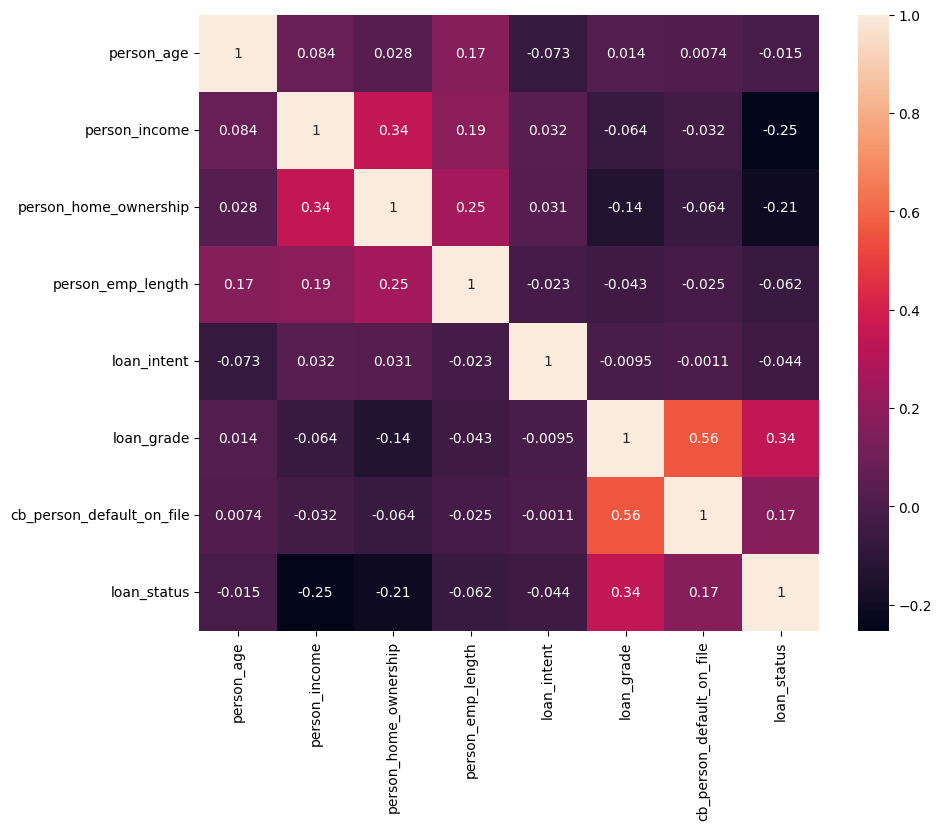

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map the string values to a number first
df2 = df.copy()
df2["loan_intent"] = df2["loan_intent"].map({"MEDICAL": 0, "PERSONAL": 1, "VENTURE": 2, "DEBTCONSOLIDATION": 3, "EDUCATION": 4})
df2["loan_grade"] = df2["loan_grade"].map({"A": 0, "B": 1, "C": 2, "D": 3})
df2["cb_person_default_on_file"] = df2["cb_person_default_on_file"].map({"N": 0, "Y": 1})
df2["person_home_ownership"] = df2["person_home_ownership"].map({"RENT": 0, "MORTGAGE": 1})

# Calculate covariance
plt.figure(figsize=(10, 8))
sns.heatmap(df2.corr(), annot=True)
plt.show()

After visualizing the dataset, let's convert the Pandas DataFrame into a NumPy array.  We will use the following conversion rules:

<center>

| Column | Pandas | NumPy |
|---|---|---|
| person_age | [20, 30) <br> [30, 40) <br> [40, 50]   | 0 <br> 1 <br> 2 |
| person_income | [0, 50000) <br> [50000, 100000) <br> [100000, 150000] | 0 <br> 1 <br> 2 |
| person_home_ownership | RENT <br> MORTGAGE | 0 <br> 1 |
| person_emp_length | [0, 10) <br> [10, 20) <br> [20, 30] | 0 <br> 1 <br> 2 |
| loan_intent | MEDICAL <br> PERSONAL <br> VENTURE <br> DEBTCONSOLIDATION <br> EDUCATION | 0 <br> 1 <br> 2 <br> 3 <br> 4 |
| loan_grade | A <br> B <br> C <br> D | 0 <br> 1 <br> 2 <br> 3 |
| cb_person_default_on_file | N <br> Y | 0 <br> 1 |
| loan_status | No need conversion | No need conversion |

</center>

Complete the following function.

<center>

| function name | parameter name | parameter datatype | return type
|---------------------------------|------------------------------------------|----------------------------|-------------------------------|
| `pandas_to_numpy` | `df` | `Pandas dataframe` | `np.ndarray`, shape (num samples, 8) |            |

</center>

In [4]:
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
#-# Task 1: Conversion to NumPy array #-#
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#

def pandas_to_numpy(df):
  """
  Converts the Pandas dataframe to a NumPy dataframe using the conversion rules stated above
  Args:
    df: the Pandas dataframe, with shape (num samples, 8)
  Returns:
    A NumPy array of shape (num samples, 8)
  """
  data = df.values # converts the pandas dataframe to a NumPy array, shape (23919, 8)

  # WRITE CODE HERE:

  # person_age (col 0)
  data[(data[:, 0] >= 20) & (data[:, 0] < 30), 0] = 0
  data[(data[:, 0] >= 30) & (data[:, 0] < 40), 0] = 1
  data[(data[:, 0] >= 40) & (data[:, 0] <= 50), 0] = 2

  # person_income (col 1)
  data[(data[:, 1] > 0) & (data[:, 1] < 50000), 1] = 0
  data[(data[:, 1] >= 50000) & (data[:, 1] < 100000), 1] = 1
  data[(data[:, 1] >= 100000) & (data[:, 1] <=150000), 1] = 2

  # person_home_ownership (col 2)
  data[data[:, 2] == 'RENT', 2] = 0
  data[data[:, 2] == 'MORTGAGE', 2] = 1

  # person_emp_length (col 3)
  data[(data[:, 3] >= 0) & (data[:, 3] < 10), 3] = 0
  data[(data[:, 3] >= 10) & (data[:, 3] < 20), 3] = 1
  data[(data[:, 3] >= 20) & (data[:, 3] <= 30), 3] = 2

  # loan_indent (col 4)
  data[data[:, 4] == 'MEDICAL', 4] = 0
  data[data[:, 4] == 'PERSONAL', 4] = 1
  data[data[:, 4] == 'VENTURE', 4] = 2
  data[data[:, 4] == 'DEBTCONSOLIDATION', 4] = 3
  data[data[:, 4] == 'EDUCATION', 4] = 4

  # loan_grade (col 5)
  data[data[:, 5] == 'A', 5] = 0
  data[data[:, 5] == 'B', 5] = 1
  data[data[:, 5] == 'C', 5] = 2
  data[data[:, 5] == 'D', 5] = 3

  # cb_person_default_on_file (col 6)
  data[data[:, 6] == 'N', 6] = 0
  data[data[:, 6] == 'Y', 6] = 1

  return data.astype(int) # converts all values to integers

data = pandas_to_numpy(df)

array([0, 0, 1, 0, 0, 2, 0, 1])

As an example, the first row, `data[0]`, returns `[0 0 1 0 0 2 0 1]`.  Using the conversion rules above, this means that the person
- is 20 - 30 years old,
- has an income of \$0 - \$50,000,
- has a mortgaged home,
- has been employed for 0 - 10 years,
- borrows the loan for medical reasons,
- borrows a grade C loan,
- has not defaulted before and
- has defaulted the current loan

## <b>Section 2:</b> Building the Classifier (3 tasks to complete)

Now that the dataset is prepared, let's start building our Naive Bayes classifier to predict the `loan status` of a particular loan.  We will first split the dataset into a training set and a testing set.  The resulting shapes will be

<center>

| variable | shape |
|---|---|
| x | (23919, 7) |
| y | (23919,) |
| x_train | (19135, 7) |
| x_test | (4784, 7) |
| y_train | (19135,) |
| y_test | (4784,) |

</center>

In [7]:
# Train-test split. This part has been done for you
from sklearn.model_selection import train_test_split

x = data[:, :-1]
y = data[:, -1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2211)

To guide you in building the full classifier, we will consider the following example. Suppose someone with the following information is applying for a loan:

<center>

| Column | Value |
|---|:---:|
| person_age | 25 years old |
| person_income | \$60,000 |
| person_home_ownership | rents his house |
| person_emp_length | 3 years |
| loan_intent | education |
| loan_grade | grade A |
| cb_person_default_on_file | never defaulted before |
| loan_status | predict this value! |

</center>

We want to determine whether the person is likely to default or not.  In other words, we want to determine which of the two beliefs—default or not default—is more likely to occur. Recall Bayes' theorem,

$$
P(B|E) = P(B) \times \frac{P(E|B)}{P(E)}
$$

where $B$ is our belief and $E$ is our evidence.  In the lectures, we have shown that with the independence and equal contribution assumptions, the above formula can be expanded and transformed so that we can approximate which belief is more likely to occur by determining which of the following two has a higher value (if you have forgotten why, it's time to review your lecture notes!):

\begin{align}
& \hspace{0.3em} \text{Belief that he will default given evidence} \\
\approx & \hspace{0.3em} P(\text{age group}|\text{default}) \times P(\text{home ownership}|\text{default}) \times \cdots \times P(\text{has defaulted before}|\text{default}) \times P(\text{default}) \\
& \hspace{0.3em} \text{Belief that he will not default given evidence} \\
\approx & \hspace{0.3em} P(\text{age group}|\text{not default}) \times P(\text{home ownership}|\text{not default}) \times \cdots \times P(\text{has defaulted before}|\text{not default}) \times P(\text{not default})
\end{align}

For the person mentioned above, this means we will need to find $P(\text{age group = 0}|\text{default}), P(\text{age group = 0}|\text{not default})$ and so on (recall that those aged [20, 30) are mapped to 0).  

- For example, to find $P(\text{age group = 0}|\text{default})$, we would need to look at all the customers who default and calculate the proportion of those whose age group is 0.  If 10 customers default and 4 of those customers belong to age group 0, then this probability would be 0.4.

Therefore, the first step would be to count the occurrences.  Complete the function `count_occurrences` below.  Since there are a total of 7 columns, a maximum of 5 possible values for each column, and 2 possible `loan_status`, the shape of the returned occurrence array should be (7, 5, 2).

<center>

| function name | parameter name | parameter datatype | return type
|---------------------------------|------------------------------------------|----------------------------|-------------------------------|
| `count_occurrences` | `x_train` <br> `y_train` | `np.ndarray`, shape (num samples, 7) <br> `np.ndarray`, shape (num samples,) | `np.ndarray`, shape (7, 5, 2) |            |

</center>

- The first table, `occurrences[:, :, 0]`, has shape `(7, 5)` and counts those who did not default.
- The second table, `occurrences[:, :, 1]`, has shape `(7, 5)` and counts those who defaulted.

As an example, indexing the returned result by `[0, :, 0]` should return the following

<center>

| function call | content |
|---------------|--------------|
| `count_occurrences(x_train, y_train)[0, :, 0]`      | `[11304,  3205,   668,     0,     0]` |

</center>

which means out of those who did not default,

- 11304 of them belong to age group 0
- 3205 of them belong to age group 1
- 668 of them belong to age group 2

and of course according to our conversion rules, the numbering for age groups stops at 2, so the remaining two are zero.

In [126]:
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
#-# Task 1: Count occurrences  #-#
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#

def count_occurrences(x_train, y_train):
  """
  Counts the number of occurrences.
  Args:
    x_train: a NumPy array of shape (num samples, 7) containing the evidence
    y_train: a NumPy array of shape (7,) containing the beliefs
  Returns:
    A NumPy array of shape (7, 5, 2), where occurrences[i, j, k] counts the number of occurrences with value j in column i, for loan status k.
    Or if you prefer it in symbols, occurrences[i, j, k] = Count(column i = j, loan_status = k)
  """
  occurrences = np.zeros((7, 5, 2), dtype=int)
  
  # WRITE CODE HERE:
  
  for i in range(7):
        for j in range(5):
            # Count occurrences for loan_status = 0 (Not Default)
            occurrences[i, j, 0] = np.sum((x_train[:, i] == j) & (y_train == 0))
            # Count occurrences for loan_staus = 1 (Default)
            occurrences[i, j, 1] = np.sum((x_train[:, i] == j) & (y_train == 1))
  
  return occurrences

Now that we have the number of occurrences, let's compute the probabilities.  Complete the following function.

<center>

| function name | parameter name | parameter datatype | return type
|---------------------------------|------------------------------------------|----------------------------|-------------------------------|
| `probit_from_occurrences` | `occurrences` | `np.ndarray`, shape (7, 5, 2) | `np.ndarray`, shape (7, 5, 2) |            |

</center>

<center>

| function call | content |
|---------------|--------------|
| `probit_from_occurrences(occurrences)[0, :, 0]`      | `[0.74481123, 0.2111748 , 0.04401397, 0.        , 0.        ]` |

</center>

which means out of those who did not default,

- 74.48% of them belong to age group 0, which is $P(\text{age group = 0 | not default})$
- 21.11% of them belong to age group 1, which is $P(\text{age group = 1 | not default})$
- 4.40% of them belong to age group 2, which is $P(\text{age group = 2 | not default})$

In [128]:
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
#-# Task 2: Compute probabilities #-#
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#

def probit_from_occurrences(occurrences):
  """
  Computes the probabilities from the occurrences.
  Args:
    occurrences: a NumPy array of shape (7, 5, 2), where indexing by [i, j, k] counts the number of occurrences with value j in column i, for loan status k.
  Returns:
    A NumPy array of shape (7, 5, 2), where indexing by [i, j, k] is P(column i = j, loan_status = k)
  """
  # WRITE CODE HERE:

  probabilities = np.zeros_like(occurrences, dtype=float)
  
  for i in range(7):
      for k in range(2):
          total_occurrences = np.sum(occurrences[i, :, k])
          
          if total_occurrences > 0:
              probabilities[i, :, k] = occurrences[i, :, k] / total_occurrences
  
  return probabilities
  

array([0.74481123, 0.2111748 , 0.04401397, 0.        , 0.        ])

Finally, let's find out if our hypothetical client mentioned above will default.  We can do this by computing the values of the two beliefs and comparing them to see which is larger.  Complete the following function.

<center>

| function name | parameter name | parameter datatype | return type
|---------------------------------|------------------------------------------|----------------------------|-------------------------------|
| `will_default` | `columns` <br> `x_train` <br> `y_train` | `np.ndarray`, shape (7,) <br> `np.ndarray`, shape (num samples, 7) <br> `np.ndarray`, shape (7,) | `bool` |            |

</center>

<center>

| function call | content |
|---------------|--------------|
| `columns = np.array([0, 1, 0, 0, 4, 0, 0])` <br> `will_default(columns, x_train, y_train)`      | `False` |

</center>

which means the client will not default.  In your computation, do not forget to multiply $P(\text{default})$ and $P(\text{non default})$ where necessary!

In [132]:
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
#-# Task 3: Make a prediction #-#
#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#

def will_default(columns, x_train, y_train):
  """
  Returns True if a person given certain columns will default.
  Args:
    columns: a NumPy array of shape (7,) with the conversion rules as stated in section 1
    x_train: a NumPy array of shape (num samples, 7) containing the evidence
    y_train: a NumPy array of shape (7,) containing the beliefs
  Returns:
    True if the person will default, False otherwise
  """
  occurrences = count_occurrences(x_train, y_train)
  probabilities = probit_from_occurrences(occurrences)

  # WRITE CODE HERE:

  probability_default = np.mean(y_train == 1)
  probability_not_default = np.mean(y_train == 0)
  
  default_prob = probability_default
  not_default_prob = probability_not_default
  
  for i, value in enumerate(columns):
      default_prob *= probabilities[i, value, 1]
      not_default_prob *= probabilities[i, value, 0]
  
  if default_prob > not_default_prob:
      return True
  else:
     return False
  


0.20684609354585837


False

## <b>Section 3:</b> Model evaluation (no tasks to complete)

Our classifier is complete, but we don't know how accurate it actually is.  Luckily, using the testing dataset we split off in Section 2, we can evaluate the performance of our classifier. We will introduce four common metrics for binary classification tasks:

- <b>Accuracy</b>: the proportion of correctly classified data points.
- <b>Precision</b>: the proportion of correctly classified positive data points among all data points classified as positive.
- <b>Recall</b>: the proportion of correctly classified positive data points among all actual positive data points.
- <b>F1 score</b>: The harmonic mean of precision and recall.

More specifically, let's define the following terms:
- <b>True Positive (TP)</b>: the number of data points that are actually positive (i.e. will default) and are classified as positive.
- <b>True Negative (TN)</b>: the number of data points that are actually negative (i.e. will not default) and are classified as negative.
- <b>False Positive (FP)</b>: the number of data points that are actually negative but are classified as positive.
- <b>False Negative (FN)</b>: the number of data points that are actually positive but are classified as negative.

Then, the metrics can be defined as:
- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 score = 2 * Precision * Recall / (Precision + Recall)

In [131]:
# A loop solution.  Very slow but writing the vectorized version would give you the answer to 'will_default'
from tqdm import tqdm
y_predicted = np.zeros((x_test.shape[0],))
for i in tqdm(range(0, x_test.shape[0])):
  if will_default(x_test[i], x_train, y_train):
    y_predicted[i] = 1

# Calculate metrics
accuracy = np.sum(y_predicted == y_test) / y_test.shape[0]
print(f"Accuracy: {accuracy}")

precision = np.sum((y_predicted == 1) & (y_test == 1)) / np.sum(y_predicted == 1)
print(f"Precision: {precision}")

recall = np.sum((y_predicted == 1) & (y_test == 1)) / np.sum(y_test == 1)
print(f"Recall: {recall}")

f1 = 2 * precision * recall / (precision + recall)
print(f"F1: {f1}")

100%|██████████| 4784/4784 [00:07<00:00, 661.96it/s]

Accuracy: 0.8221153846153846
Precision: 0.6289424860853432
Recall: 0.3424242424242424
F1: 0.4434270765206017
